# **IA para DEVs - 8IADT - Fase 3**

## **Tech Challenge - Assistente Medico Hospitalar**
### **Grupo 49**
### **Integrantes**:
- Rodrigo de Araújo Rosa
- Elias Maximiano da Silva
- Fábia Gomes de Jesus
- Danilo Pereira

### **Desafio**
Após o sucesso na automação de análises de exames e textos clínicos, o hospital quer avançar para
um nível superior de personalização: criar um assistente virtual médico, treinado com os dados
próprios do hospital, capaz de auxiliar nas condutas clínicas, responder dúvidas de médicos e
sugerir procedimentos com base nos protocolos internos.

---

# **Assistente Médico Hospitalar — LangChain RAG LangGraph Pipeline**
### *Mistral-7B + QLoRA + LangGraph + ChromaDB + Prontuários*

Notebook **completamente autocontido** com pipeline orquestrado por **LangGraph**.

O fluxo de uma consulta é modelado como um **grafo de estados** com nós independentes e arestas condicionais explícitas:

```
START
  │
  ▼
[detectar_prescricao]
  │
  ├─(prescrição)────────────────────────► [recusar_prescricao]
  │                                                │
  └─(ok)                                           │
       ▼                                           │
[identificar_paciente]                             │
  │                                                │
  ├─(encontrado)──► [rag_paciente]                 │
  │                      │                         │
  │               [buscar_alertas]                 │
  │                      │                         │
  └─(genérico)──────► [rag_generico]               │
                          │                        │
                          ▼                        │
                    [invocar_llm]                  │
                          │                        │
                          ▼                        │
                  [formatar_resposta] ◄────────────┘
                          │
                  [registrar_log]
                          │
                         END
```

> **Pré-requisito:** Execute em sessão do Google Colab com GPU (T4 ou L4).

## **Índice**
1. Instalar Dependências
2. Montar Google Drive
3. Imports, Modelos de Dados e Prompts
4. Carregar Prontuários e Construir Índice ChromaDB
5. Carregar Modelo Fine-Tunado
6. Grafo LangGraph - Estado e Nós
7. Construir o Grafo LangGraph
8. Visualizar o Grafo
9. Função de Entrada do Pipeline
10. Testar o Pipeline
11. Interface Gradio com URL Pública

## 1. INSTALAR DEPENDÊNCIAS

In [1]:
%%time
!pip install -q -U \
    transformers \
    peft \
    accelerate \
    bitsandbytes \
    langchain \
    langchain-community \
    langchain-huggingface \
    langchain-text-splitters \
    langchain-core \
    langchain-chroma \
    langgraph \
    sentence-transformers \
    chromadb \
    jq \
    gradio

print("✅ Dependências instaladas.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 153.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.1/114.1 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 121.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 49.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 234.3/234.3 kB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 588.7/588.7 kB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 121.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 773.8/773.8 kB 57.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.7/19.7 MB 105.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 2. MONTAR GOOGLE DRIVE

In [2]:
import os
from google.colab import drive

drive.mount("/content/drive")

DRIVE_BASE = "/content/drive/MyDrive/assistente-medico"
LOG_DIR    = f"{DRIVE_BASE}/logs"
CHROMA_DIR = f"{DRIVE_BASE}/chromadb"

os.makedirs(LOG_DIR,    exist_ok=True)
os.makedirs(CHROMA_DIR, exist_ok=True)

print("✅ Google Drive montado.")
print(f"   Logs de auditoria  : {LOG_DIR}")
print(f"   ChromaDB persistido: {CHROMA_DIR}")

Mounted at /content/drive
✅ Google Drive montado.
   Logs de auditoria  : /content/drive/MyDrive/assistente-medico/logs
   ChromaDB persistido: /content/drive/MyDrive/assistente-medico/chromadb


## 3. IMPORTS, MODELOS DE DADOS E PROMPTS

In [16]:
import json
import os
import unicodedata
from dataclasses import dataclass, field
from datetime import datetime, timezone
from difflib import SequenceMatcher
from enum import Enum
from typing import Optional


def _normalize(text: str) -> str:
    """Remove acentos e converte para lowercase."""
    nfkd = unicodedata.normalize("NFKD", text)
    return "".join(c for c in nfkd if not unicodedata.combining(c)).lower().strip()


# Enums

class AlertType(str, Enum):
    EXAME_PENDENTE = "EXAME_PENDENTE"
    EXAME_ALTERADO = "EXAME_ALTERADO"

class AlertPriority(str, Enum):
    ALTA  = "ALTA"
    MEDIA = "MEDIA"
    BAIXA = "BAIXA"


# Dataclasses

@dataclass
class ClinicalAlert:
    tipo: AlertType
    prioridade: AlertPriority
    descricao: str
    exames_afetados: list = field(default_factory=list)

    def __post_init__(self):
        if isinstance(self.tipo, str):
            self.tipo = AlertType(self.tipo)
        if isinstance(self.prioridade, str):
            self.prioridade = AlertPriority(self.prioridade)

@dataclass
class ResponseSources:
    dados_prontuario: list    = field(default_factory=list)
    conhecimento_modelo: bool = False
    paciente_encontrado: bool = False

@dataclass
class MedicalResponse:
    resposta: str
    fontes: ResponseSources
    alertas: list
    timestamp: str
    consulta_original: str

    def __post_init__(self):
        if isinstance(self.fontes, dict):
            self.fontes = ResponseSources(**self.fontes)


# Prompt Templates

MEDICAL_SYSTEM_PROMPT = (
    "Você é um assistente médico hospitalar especializado.\n"
    "Responda SEMPRE em Português Brasileiro.\n"
    "Use as informações do prontuário fornecidas para contextualizar sua resposta.\n"
    "Quando a consulta for relacionada a exames pendentes ou alterados, seja mais direto nas respostas.\n"
    "IMPORTANTE: Toda sugestão clínica requer validação de profissional de saúde habilitado.\n"
    "Não gere prescrições médicas diretas."
)

MEDICAL_RAG_TEMPLATE = (
    "Contexto do prontuário:\n"
    "{context}\n\n"
    "Consulta do médico: {question}\n\n"
    "Resposta:"
)

PRESCRIPTION_REFUSAL_MESSAGE = (
    "Não é possível gerar prescrições médicas diretas. "
    "A emissão de prescrições está fora do escopo deste assistente e requer "
    "avaliação e assinatura de um profissional de saúde habilitado. "
    "Posso auxiliar com informações clínicas gerais, revisão de prontuários "
    "e sugestões de condutas que devem ser validadas pelo médico responsável."
)

HUMAN_VALIDATION_WARNING = (
    "\n\n⚠️ AVISO: Esta resposta contém sugestões clínicas que requerem "
    "validação e aprovação de um profissional de saúde habilitado antes de "
    "serem adotadas. O assistente não substitui o julgamento clínico médico."
)

PATIENT_NOT_FOUND_PREFIX = (
    "Não foram encontrados dados de prontuário para o paciente mencionado "
    "na base de dados. A resposta a seguir é baseada exclusivamente no "
    "conhecimento do modelo:\n\n"
)

GENERIC_ERROR_MESSAGE = (
    "Ocorreu um erro interno ao processar sua consulta. Por favor, tente novamente."
)

PRESCRIPTION_KEYWORDS = [
    "prescrição", "prescrever", "prescreva", "prescrito",
    "receita médica", "receitar", "receite", "prescribe",
    "prescription", "receituário", "receituario",
]

CLINICAL_SUGGESTION_KEYWORDS = [
    "sugiro", "sugere", "recomendo", "recomenda", "recomendado",
    "indicado", "indica-se", "protocolo", "conduta", "tratamento",
    "medicamento", "dose", "dosagem", "terapia", "terapêutica",
    "terapeutica", "intervenção", "intervencao", "procedimento",
    "cirurgia", "exame", "solicitar", "administrar", "iniciar",
    "suspender", "ajustar",
]

print("✅ Imports, modelos de dados e prompts carregados.")

✅ Imports, modelos de dados e prompts carregados.


## 4. CARREGAR PRONTUÁRIOS E CONSTRUIR ÍNDICE CHROMADB

In [4]:
%%time
import torch
import urllib.request

PRONTUARIOS_URL  = (
    "https://raw.githubusercontent.com/rodrigoaraujorosa/"
    "fiap-ia-devs-8iadt-fase3-tech-challenge/refs/heads/develop/data/prontuarios.json"
)
PRONTUARIOS_PATH = "/content/prontuarios.json"
EMBEDDING_MODEL  = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"
COLLECTION_NAME  = "prontuarios_hospitalar"

if not os.path.exists(PRONTUARIOS_PATH):
    urllib.request.urlretrieve(PRONTUARIOS_URL, PRONTUARIOS_PATH)
    print("✅ prontuarios.json baixado.")
else:
    print("✅ prontuarios.json já disponível.")


def _decode_page_content(docs: list) -> list:
    """Corrige \\uXXXX do JSONLoader re-serializando com ensure_ascii=False."""
    for doc in docs:
        try:
            doc.page_content = json.dumps(
                json.loads(doc.page_content), ensure_ascii=False
            )
        except (json.JSONDecodeError, TypeError):
            pass
    return docs


def build_chromadb_index(prontuarios_path: str, chroma_dir: str):
    """Constrói ou carrega índice ChromaDB com JSONLoader + embeddings multilinguais."""
    import chromadb
    from langchain_community.document_loaders import JSONLoader
    from langchain_text_splitters import RecursiveCharacterTextSplitter
    from langchain_huggingface import HuggingFaceEmbeddings
    from langchain_chroma import Chroma

    device = "cuda" if torch.cuda.is_available() else "cpu"
    embeddings = HuggingFaceEmbeddings(
        model_name=EMBEDDING_MODEL,
        model_kwargs={"device": device},
        encode_kwargs={"normalize_embeddings": True, "batch_size": 32},
    )

    def _meta_prontuario(record: dict, metadata: dict) -> dict:
        metadata["patient_id"]   = record.get("id", "")
        metadata["nome"]         = record.get("nome", "")
        metadata["sexo"]         = record.get("sexo", "")
        metadata["diagnosticos"] = "; ".join(record.get("diagnosticos", []))
        metadata["doc_type"]     = "prontuario"
        return metadata

    def _meta_exame(record: dict, metadata: dict) -> dict:
        metadata["patient_id"]    = record.get("paciente_id", "")
        metadata["nome_paciente"] = record.get("nome_paciente", "")
        metadata["exame_id"]      = record.get("id", "")
        metadata["exame_nome"]    = record.get("nome", "")
        metadata["status"]        = record.get("status", "")
        metadata["diagnosticos"]  = "; ".join(record.get("diagnosticos", []))
        metadata["doc_type"]      = "exame"
        return metadata

    JQ_EXAME = (
        ".prontuarios[] | . as $p | .exames[] "
        "| {paciente_id: $p.id, nome_paciente: $p.nome, sexo: $p.sexo, "
        "   diagnosticos: $p.diagnosticos, medicamentos: $p.medicamentos_em_uso} + ."
    )

    docs = _decode_page_content(
        JSONLoader(file_path=prontuarios_path, jq_schema=".prontuarios[]",
                   text_content=False, metadata_func=_meta_prontuario).load()
    ) + _decode_page_content(
        JSONLoader(file_path=prontuarios_path, jq_schema=JQ_EXAME,
                   text_content=False, metadata_func=_meta_exame).load()
    )

    chunks = RecursiveCharacterTextSplitter(
        chunk_size=800, chunk_overlap=100,
        separators=["\n\n", "\n", ", ", " ", ""],
    ).split_documents(docs)

    chroma_client = chromadb.PersistentClient(path=chroma_dir)
    existing      = [c.name for c in chroma_client.list_collections()]

    if COLLECTION_NAME in existing:
        print(f"♻️  Coleção '{COLLECTION_NAME}' já existe — carregando do disco...")
        db = Chroma(client=chroma_client, collection_name=COLLECTION_NAME,
                    embedding_function=embeddings)
    else:
        print(f"🔨 Indexando {len(chunks)} chunks no ChromaDB...")
        db = Chroma.from_documents(documents=chunks, embedding=embeddings,
                                   client=chroma_client, collection_name=COLLECTION_NAME)

    print(f"✅ ChromaDB: {db._collection.count()} chunks | device: {device}")
    return db, chroma_client


def _load_patient_names(collection) -> dict:
    """Retorna {patient_id: nome} a partir dos metadados de chunks de prontuário."""
    result = collection.get(
        where={"doc_type": {"$eq": "prontuario"}},
        include=["metadatas"],
    )
    return {
        m["patient_id"]: m["nome"]
        for m in result["metadatas"]
        if m.get("patient_id") and m.get("nome")
    }


print("Construindo índice ChromaDB...")
vectordb, _chroma_client = build_chromadb_index(PRONTUARIOS_PATH, CHROMA_DIR)
chroma_collection        = _chroma_client.get_collection(COLLECTION_NAME)
_PATIENT_NAMES           = _load_patient_names(chroma_collection)

print(f"✅ {len(_PATIENT_NAMES)} pacientes no índice de nomes.")

✅ prontuarios.json baixado.
Construindo índice ChromaDB...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

♻️  Coleção 'prontuarios_hospitalar' já existe — carregando do disco...
✅ ChromaDB: 217 chunks | device: cuda
✅ 20 pacientes no índice de nomes.
CPU times: user 27.4 s, sys: 6.14 s, total: 33.6 s
Wall time: 46.4 s


## 5. CARREGAR MODELO FINE-TUNADO (QLoRA 4-bit)

> ⏳ Esta etapa pode levar **15–30 minutos** dependendo da GPU e velocidade de download.

In [5]:
%%time
import warnings
import logging as _logging

warnings.filterwarnings("ignore")
_logging.getLogger("transformers").setLevel(_logging.ERROR)

from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    GenerationConfig,
    pipeline as hf_pipeline,
)
from peft import PeftModel

BASE_MODEL_ID   = "mistralai/Mistral-7B-Instruct-v0.2"
ADAPTER_REPO_ID = "rodrigoaraujorosa/mistral-7b-assistente-hospitalar-v1"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

print("Carregando modelo base...")
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
)

print("Carregando tokenizer...")
tokenizer             = AutoTokenizer.from_pretrained(BASE_MODEL_ID)
tokenizer.pad_token   = tokenizer.eos_token

print(f"Aplicando adaptador LoRA: {ADAPTER_REPO_ID}")
model                 = PeftModel.from_pretrained(base_model, ADAPTER_REPO_ID)
model.eval()
model.generation_config = GenerationConfig(
    pad_token_id=tokenizer.eos_token_id,
    eos_token_id=tokenizer.eos_token_id,
)

llm_pipeline = hf_pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    device_map="auto",
    max_new_tokens=1024,
    do_sample=True,
    temperature=0.6,
    top_p=0.85,
    repetition_penalty=1.1,
)

vram_used = torch.cuda.memory_allocated() / 1024**3
print(f"\n✅ Modelo pronto! VRAM utilizada: {vram_used:.2f} GB")

Carregando modelo base...


config.json:   0%|          | 0.00/596 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

...

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

Aplicando adaptador LoRA: rodrigoaraujorosa/mistral-7b-assistente-hospitalar-v1


adapter_config.json: 0.00B [00:00, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/671M [00:00<?, ?B/s]


✅ Modelo pronto! VRAM utilizada: 5.51 GB
CPU times: user 1min 6s, sys: 35.1 s, total: 1min 42s
Wall time: 1min


## 6. GRAFO LANGGRAPH — ESTADO E NÓS

Define o `GraphState` (TypedDict) e as **8 funções de nó** do pipeline:

| Nó | Responsabilidade |
|---|---|
| `detectar_prescricao` | Verifica se a consulta solicita prescrição |
| `identificar_paciente` | Fuzzy-match do nome do paciente na query |
| `rag_paciente` | RAG filtrado por `patient_id` — recupera chunks do prontuário |
| `buscar_alertas` | Alertas clínicos via metadados do ChromaDB |
| `rag_generico` | RAG sem filtro para queries genéricas |
| `invocar_llm` | Monta prompt Mistral Instruct e chama o modelo |
| `formatar_resposta` | Monta `MedicalResponse` estruturado |
| `recusar_prescricao` | Resposta de recusa (atalho sem LLM) |
| `registrar_log` | Persiste interação no audit log |

In [6]:
from typing import TypedDict, Optional


# Estado do grafo

class GraphState(TypedDict):
    """Estado compartilhado entre todos os nós do pipeline."""
    consulta:            str
    is_prescription:     bool
    patient_id:          Optional[str]
    patient_nome:        Optional[str]
    paciente_encontrado: bool
    retrieved_docs:      list
    alertas:             list
    context:             str
    raw_response:        str
    response:            Optional[object]   # MedicalResponse


# Helpers

_STEP_WIDTH = 60

def _log_step(icon: str, nome: str, detalhe: str = "") -> None:
    """Imprime linha de rastreamento do fluxo com largura fixa."""
    label = f"{icon} {nome}"
    if detalhe:
        print(f"  {label:<{_STEP_WIDTH}} {detalhe}")
    else:
        print(f"  {label}")


def _find_patient_in_query(consulta: str) -> tuple:
    """Detecta nome de paciente na query via fuzzy match com pré-filtro de tokens."""
    consulta_norm   = _normalize(consulta)
    consulta_tokens = set(consulta_norm.split())
    best_ratio, best_pid, best_nome = 0.0, None, None

    for pid, nome in _PATIENT_NAMES.items():
        nome_norm   = _normalize(nome)
        nome_tokens = set(nome_norm.split())

        # Pré-filtro: pelo menos um token do nome deve aparecer na query.
        if not nome_tokens & consulta_tokens:
            continue

        if nome_norm in consulta_norm or consulta_norm in nome_norm:
            return pid, nome

        ratio = max(
            SequenceMatcher(None, consulta_norm, nome_norm).ratio(),
            max(
                (SequenceMatcher(None, qt, nt).ratio()
                 for qt in consulta_norm.split()
                 for nt in nome_norm.split()),
                default=0.0,
            ),
        )
        if ratio >= 0.6 and ratio > best_ratio:
            best_ratio, best_pid, best_nome = ratio, pid, nome

    return best_pid, best_nome


def _has_clinical_suggestion(text: str) -> bool:
    return any(_normalize(kw) in _normalize(text) for kw in CLINICAL_SUGGESTION_KEYWORDS)


# Nós do grafo

def node_detectar_prescricao(state: GraphState) -> GraphState:
    """Verifica se a consulta solicita geração de prescrição médica."""
    consulta_norm   = _normalize(state["consulta"])
    is_prescription = any(
        _normalize(kw) in consulta_norm for kw in PRESCRIPTION_KEYWORDS
    )
    preview  = state["consulta"][:55] + "..." if len(state["consulta"]) > 55 else state["consulta"]
    resultado = "⛔ prescrição detectada → recusando" if is_prescription else "✅ consulta permitida"
    _log_step("🔍", "detectar_prescricao", f'"{preview}"')
    _log_step("  ", "",                    f"→ {resultado}")
    return {**state, "is_prescription": is_prescription}


def node_identificar_paciente(state: GraphState) -> GraphState:
    """Detecta nome de paciente na query e atualiza o estado."""
    patient_id, patient_nome = _find_patient_in_query(state["consulta"])
    if patient_id:
        _log_step("👤", "identificar_paciente", f"→ paciente encontrado: {patient_nome}  (id: {patient_id})")
    else:
        _log_step("👤", "identificar_paciente", "→ nenhum paciente identificado — modo genérico")
    return {
        **state,
        "patient_id":          patient_id,
        "patient_nome":        patient_nome,
        "paciente_encontrado": patient_id is not None,
    }


def node_rag_paciente(state: GraphState) -> GraphState:
    """RAG filtrado pelo patient_id — recupera chunks do prontuário do paciente."""
    retrieved_docs = vectordb.similarity_search(
        state["consulta"], k=3, filter={"patient_id": state["patient_id"]}
    )
    context = "\n\n---\n\n".join(doc.page_content for doc in retrieved_docs)
    _log_step("📄", "rag_paciente",
              f"→ {len(retrieved_docs)} chunk(s) recuperado(s) para '{state['patient_nome']}'")
    return {**state, "retrieved_docs": retrieved_docs, "context": context}


def node_buscar_alertas(state: GraphState) -> GraphState:
    """Consulta metadados do ChromaDB e gera alertas clínicos do paciente identificado."""
    patient_id   = state["patient_id"]
    patient_nome = state["patient_nome"]
    alertas      = []

    contadores = {}
    for status, alert_type, prioridade, msg in [
        ("alterado", AlertType.EXAME_ALTERADO, AlertPriority.ALTA,
         "exame(s) com resultado alterado que requer(em) atenção imediata."),
        ("pendente", AlertType.EXAME_PENDENTE, AlertPriority.MEDIA,
         "exame(s) pendente(s) aguardando resultado."),
    ]:
        result = chroma_collection.get(
            where={"$and": [
                {"patient_id": {"$eq": patient_id}},
                {"status":     {"$eq": status}},
                {"doc_type":   {"$eq": "exame"}},
            ]},
            include=["metadatas"],
        )
        nomes = list({m["exame_nome"] for m in result["metadatas"] if m.get("exame_nome")})
        contadores[status] = len(nomes)
        if nomes:
            alertas.append(ClinicalAlert(
                tipo=alert_type, prioridade=prioridade,
                descricao=f"Paciente {patient_nome} possui {len(nomes)} {msg}",
                exames_afetados=nomes,
            ))

    resumo = ", ".join(f"{v} {k}" for k, v in contadores.items() if v > 0) or "nenhum"
    _log_step("🚨", "buscar_alertas",
              f"→ {len(alertas)} alerta(s) gerado(s)  [{resumo}]")
    return {**state, "alertas": alertas}


def node_rag_generico(state: GraphState) -> GraphState:
    """RAG sem filtro de paciente para queries genéricas."""
    retrieved_docs = vectordb.similarity_search(state["consulta"], k=5)
    context        = "\n\n---\n\n".join(doc.page_content for doc in retrieved_docs)
    _log_step("🌐", "rag_generico",
              f"→ {len(retrieved_docs)} chunk(s) recuperado(s) sem filtro de paciente")
    return {**state, "retrieved_docs": retrieved_docs, "alertas": [], "context": context}


def node_invocar_llm(state: GraphState) -> GraphState:
    """Monta prompt no formato Mistral Instruct e gera resposta."""
    context = state.get("context") or "Nenhum contexto disponível."
    inner   = MEDICAL_SYSTEM_PROMPT + "\n\n" + MEDICAL_RAG_TEMPLATE.format(
        context=context, question=state["consulta"]
    )
    prompt  = f"<s>[INST] {inner} [/INST]"

    _log_step("🤖", "invocar_llm",
              f"→ prompt: {len(prompt):,} chars — aguardando geração...")

    result       = llm_pipeline(prompt)
    generated    = result[0].get("generated_text", "")
    raw_response = generated.split("[/INST]")[-1].strip() or (
        "Não foi possível gerar uma resposta."
    )

    _log_step("  ", "",
              f"→ resposta: {len(raw_response):,} chars gerados")
    return {**state, "raw_response": raw_response}


def node_formatar_resposta(state: GraphState) -> GraphState:
    """Monta MedicalResponse estruturado a partir do estado atual."""
    raw_response        = state.get("raw_response", "")
    retrieved_docs      = state.get("retrieved_docs", [])
    paciente_encontrado = state.get("paciente_encontrado", False)
    alertas             = state.get("alertas", [])

    dados_prontuario = []
    if retrieved_docs and paciente_encontrado:
        markers = {
            "diagnosticos": "diagnosticos",
            "medicamentos":  "medicamentos_em_uso",
            "observacoes":   "observacoes_gerais",
            "exames":        "exames",
            "paciente_id":   "dados_basicos",
        }
        found = set()
        for doc in retrieved_docs:
            for marker, field_name in markers.items():
                if f'"{marker}"' in doc.page_content:
                    found.add(field_name)
        dados_prontuario = sorted(found)

    fontes = ResponseSources(
        dados_prontuario=dados_prontuario,
        conhecimento_modelo=True,
        paciente_encontrado=paciente_encontrado,
    )

    resposta = raw_response
    if not paciente_encontrado and not retrieved_docs:
        resposta = PATIENT_NOT_FOUND_PREFIX + resposta
    if _has_clinical_suggestion(resposta):
        resposta += HUMAN_VALIDATION_WARNING

    fonte_lines = ["\n\n---\n📋 **Fontes da Resposta**"]
    if fontes.paciente_encontrado and fontes.dados_prontuario:
        fonte_lines.append(f"• Dados do prontuário (via RAG): {', '.join(fontes.dados_prontuario)}")
    elif fontes.paciente_encontrado:
        fonte_lines.append("• Dados do prontuário (via RAG): informações gerais do paciente")
    else:
        fonte_lines.append("• Dados do prontuário (via RAG): contexto geral da base de prontuários")
    fonte_lines.append(
        "• Conhecimento do modelo: base de perguntas e respostas "
        "aprendidos durante o treinamento"
    )
    resposta += "\n".join(fonte_lines)

    campos = ", ".join(dados_prontuario) if dados_prontuario else "contexto geral"
    _log_step("📝", "formatar_resposta",
              f"→ campos RAG: {campos}  |  alertas: {len(alertas)}")

    response = MedicalResponse(
        resposta=resposta, fontes=fontes, alertas=alertas,
        timestamp=datetime.now(tz=timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ"),
        consulta_original=state["consulta"],
    )
    return {**state, "response": response}


def node_recusar_prescricao(state: GraphState) -> GraphState:
    """Retorna resposta de recusa sem invocar a LLM."""
    _log_step("🚫", "recusar_prescricao", "→ emitindo recusa sem chamar a LLM")
    response = MedicalResponse(
        resposta=PRESCRIPTION_REFUSAL_MESSAGE,
        fontes=ResponseSources(
            dados_prontuario=[], conhecimento_modelo=False, paciente_encontrado=False
        ),
        alertas=[],
        timestamp=datetime.now(tz=timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ"),
        consulta_original=state["consulta"],
    )
    return {**state, "response": response}


def node_registrar_log(state: GraphState) -> GraphState:
    """Persiste a interação no audit log e retorna o estado sem modificações."""
    resp  = state["response"]
    entry = {
        "timestamp":           datetime.now(tz=timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ"),
        "event_type":          "INTERACTION",
        "consulta":            state["consulta"],
        "paciente_encontrado": resp.fontes.paciente_encontrado,
        "alertas":             len(resp.alertas),
        "resposta_preview":    resp.resposta[:200],
    }
    try:
        with open(f"{LOG_DIR}/audit.log", "a", encoding="utf-8") as f:
            f.write(json.dumps(entry, ensure_ascii=False) + "\n")
        _log_step("💾", "registrar_log", f"→ entrada salva em audit.log")
    except Exception as exc:
        _log_step("⚠️", "registrar_log", f"→ erro ao salvar log: {exc}")
    print()
    return state


print("✅ GraphState e nós do pipeline definidos.")

✅ GraphState e nós do pipeline definidos.


## 7. CONSTRUIR O GRAFO LANGGRAPH

Registra os nós, define as arestas condicionais e compila o grafo.

In [7]:
from langgraph.graph import StateGraph, END

# Funções de roteamento (arestas condicionais)

def route_prescricao(state: GraphState) -> str:
    """Após detectar_prescricao: desvia para recusa ou segue o fluxo normal."""
    return "recusar_prescricao" if state["is_prescription"] else "identificar_paciente"


def route_paciente(state: GraphState) -> str:
    """Após identificar_paciente: escolhe RAG específico ou genérico."""
    return "rag_paciente" if state["paciente_encontrado"] else "rag_generico"


# Construção do grafo

workflow = StateGraph(GraphState)

# Registrar nós
workflow.add_node("detectar_prescricao",  node_detectar_prescricao)
workflow.add_node("identificar_paciente", node_identificar_paciente)
workflow.add_node("rag_paciente",         node_rag_paciente)
workflow.add_node("buscar_alertas",       node_buscar_alertas)
workflow.add_node("rag_generico",         node_rag_generico)
workflow.add_node("invocar_llm",          node_invocar_llm)
workflow.add_node("formatar_resposta",    node_formatar_resposta)
workflow.add_node("recusar_prescricao",   node_recusar_prescricao)
workflow.add_node("registrar_log",        node_registrar_log)

# Ponto de entrada
workflow.set_entry_point("detectar_prescricao")

# Arestas condicionais
workflow.add_conditional_edges(
    "detectar_prescricao",
    route_prescricao,
    {
        "recusar_prescricao":  "recusar_prescricao",
        "identificar_paciente": "identificar_paciente",
    },
)
workflow.add_conditional_edges(
    "identificar_paciente",
    route_paciente,
    {
        "rag_paciente": "rag_paciente",
        "rag_generico": "rag_generico",
    },
)

# Arestas diretas
workflow.add_edge("rag_paciente",       "buscar_alertas")   # alertas após RAG específico
workflow.add_edge("buscar_alertas",     "invocar_llm")
workflow.add_edge("rag_generico",       "invocar_llm")      # genérico vai direto para LLM
workflow.add_edge("invocar_llm",        "formatar_resposta")
workflow.add_edge("formatar_resposta",  "registrar_log")
workflow.add_edge("recusar_prescricao", "registrar_log")
workflow.add_edge("registrar_log",      END)

# Compilar
graph = workflow.compile()

print("✅ Grafo LangGraph compilado com sucesso.")

✅ Grafo LangGraph compilado com sucesso.


## 8. VISUALIZAR O GRAFO

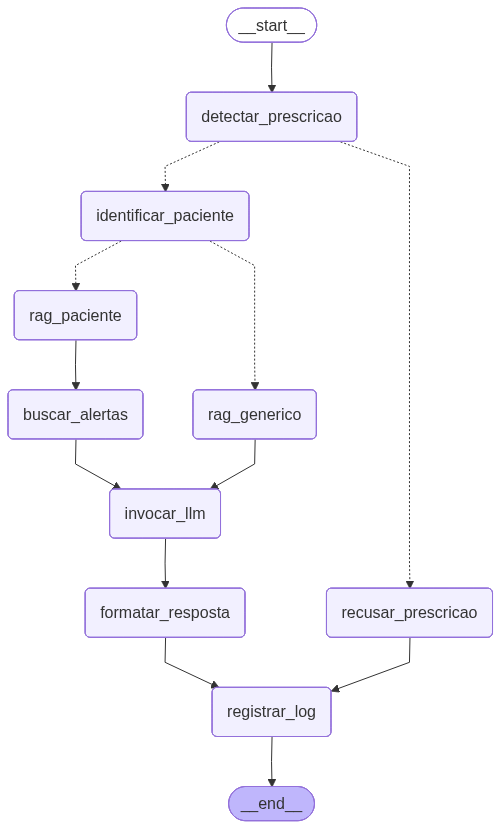

In [8]:
from IPython.display import Image, display

try:
    img_bytes = graph.get_graph().draw_mermaid_png()
    display(Image(img_bytes))
except Exception as exc:
    # Fallback: exibe representação Mermaid em texto
    print("Visualização PNG indisponível:", exc)
    print()
    print(graph.get_graph().draw_mermaid())

## 9. FUNÇÃO DE ENTRADA DO PIPELINE

Wrapper que inicializa o estado e invoca o grafo compilado.

In [9]:
def consultar(consulta: str) -> MedicalResponse:
    """Executa o pipeline LangGraph para uma consulta médica."""
    consulta = consulta.strip()
    if not consulta:
        raise ValueError("Consulta não pode ser vazia.")

    initial_state: GraphState = {
        "consulta":            consulta,
        "is_prescription":     False,
        "patient_id":          None,
        "patient_nome":        None,
        "paciente_encontrado": False,
        "retrieved_docs":      [],
        "alertas":             [],
        "context":             "",
        "raw_response":        "",
        "response":            None,
    }

    final_state = graph.invoke(initial_state)
    return final_state["response"]


print("✅ Função consultar() pronta.")

✅ Função consultar() pronta.


## 10. TESTAR O PIPELINE

In [18]:
# Consulta 1: paciente específico
resp = consultar("Quais exames estão pendentes para José Antônio Pereira?")

print("=" * 70)
print("CONSULTA:", resp.consulta_original)
print("=" * 70)
print(resp.resposta)

if resp.alertas:
    print("\n🚨 ALERTAS CLÍNICOS:")
    for a in resp.alertas:
        print(f"  [{a.prioridade.value}] {a.tipo.value}: {a.descricao}")
        print(f"  Exames: {', '.join(a.exames_afetados)}")

  🔍 detectar_prescricao                                        "Quais exames estão pendentes para José Antônio Pereira?"
                                                               → ✅ consulta permitida
  👤 identificar_paciente                                       → paciente encontrado: José Antônio Pereira  (id: P006)
  📄 rag_paciente                                               → 3 chunk(s) recuperado(s) para 'José Antônio Pereira'
  🚨 buscar_alertas                                             → 2 alerta(s) gerado(s)  [2 alterado, 1 pendente]
  🤖 invocar_llm                                                → prompt: 2,569 chars — aguardando geração...
                                                               → resposta: 155 chars gerados
  📝 formatar_resposta                                          → campos RAG: dados_basicos, diagnosticos, exames, medicamentos_em_uso  |  alertas: 2
  💾 registrar_log                                              → entrada salva em audit.log


In [14]:
# Consulta 2: query genérica (sem nome de paciente)
resp2 = consultar("Qual o tratamento recomendado para asma?")

print("=" * 70)
print("CONSULTA:", resp2.consulta_original)
print("=" * 70)
print(resp2.resposta)
print("\nPaciente encontrado:", resp2.fontes.paciente_encontrado)

  🔍 detectar_prescricao                                        "Qual o tratamento recomendado para asma?"
                                                               → ✅ consulta permitida
  👤 identificar_paciente                                       → nenhum paciente identificado — modo genérico
  🌐 rag_generico                                               → 5 chunk(s) recuperado(s) sem filtro de paciente
  🤖 invocar_llm                                                → prompt: 3,255 chars — aguardando geração...
                                                               → resposta: 232 chars gerados
  📝 formatar_resposta                                          → campos RAG: contexto geral  |  alertas: 0
  💾 registrar_log                                              → entrada salva em audit.log

CONSULTA: Qual o tratamento recomendado para asma?
A adição de LABA aos corticosteróides inalados pode ser considerada como uma opção terapêutica em pacientes com dispneia mais jovens

In [21]:
# Consulta 3: solicitação de prescrição (deve ser recusada sem chamar a LLM)
resp3 = consultar("Gere uma prescrição médica para o paciente João Silva.")

print("=" * 70)
print("CONSULTA:", resp3.consulta_original)
print("=" * 70)
print(resp3.resposta)

  🔍 detectar_prescricao                                        "Gere uma prescrição médica para o paciente João Silva."
                                                               → ⛔ prescrição detectada → recusando
  🚫 recusar_prescricao                                         → emitindo recusa sem chamar a LLM
  💾 registrar_log                                              → entrada salva em audit.log

CONSULTA: Gere uma prescrição médica para o paciente João Silva.
Não é possível gerar prescrições médicas diretas. A emissão de prescrições está fora do escopo deste assistente e requer avaliação e assinatura de um profissional de saúde habilitado. Posso auxiliar com informações clínicas gerais, revisão de prontuários e sugestões de condutas que devem ser validadas pelo médico responsável.


In [22]:
# Verificar log salvo no Google Drive
log_path = f"{LOG_DIR}/audit.log"
if os.path.exists(log_path):
    with open(log_path, encoding="utf-8") as f:
        linhas = f.readlines()
    print(f"📋 {len(linhas)} entrada(s) no log ({log_path}):")
    for linha in linhas[-3:]:
        entry = json.loads(linha)
        print(f"  [{entry['timestamp']}] {entry['event_type']} — {entry.get('consulta','')[:60]}")
else:
    print("Log ainda não criado.")

📋 101 entrada(s) no log (/content/drive/MyDrive/assistente-medico/logs/audit.log):
  [2026-05-13T22:33:29Z] INTERACTION — Quais exames estão pendentes para José Antônio Pereira?
  [2026-05-13T22:34:39Z] INTERACTION — Qual o estado atual dos exames do paciente Carlos Eduardo Me
  [2026-05-13T22:36:02Z] INTERACTION — Gere uma prescrição médica para o paciente João Silva.


## 11. INTERFACE GRADIO COM URL PÚBLICA PARA DEMONSTRAÇÃO EM VÍDEO

A célula abaixo sobe uma interface interativa com **URL pública válida por 72 horas**.

In [19]:
import gradio as gr


def gradio_consultar(consulta: str) -> tuple:
    if not consulta.strip():
        return "Por favor, digite uma consulta.", "", ""
    try:
        resp = consultar(consulta)

        alertas_txt = (
            "\n".join(
                f"🚨 [{a.prioridade.value}] {a.tipo.value}\n"
                f"   {a.descricao}\n"
                f"   Exames: {', '.join(a.exames_afetados)}"
                for a in resp.alertas
            )
            if resp.alertas
            else "Nenhum alerta clínico identificado."
        )

        fontes_txt = (
            f"Paciente encontrado: {'Sim' if resp.fontes.paciente_encontrado else 'Não'}\n"
            f"Dados do prontuário (RAG): {', '.join(resp.fontes.dados_prontuario) or 'nenhum'}\n"
            f"Conhecimento do modelo: {'Sim' if resp.fontes.conhecimento_modelo else 'Não'}\n"
            f"Timestamp: {resp.timestamp}"
        )

        return resp.resposta, alertas_txt, fontes_txt

    except Exception as exc:
        return GENERIC_ERROR_MESSAGE, "", ""


exemplos = [
    ["Quais exames estão pendentes para José Antônio Pereira?"],
    ["Qual o estado atual dos exames do paciente Carlos Eduardo Mendes?"],
    ["Qual o tratamento recomendado para anemia ferropriva?"],
    ["Gere uma prescrição médica para o paciente João Silva."],
]

with gr.Blocks(theme=gr.themes.Soft(), title="Assistente Médico Hospitalar — LangGraph RAG") as demo:

    gr.Markdown(
        "# 🏥 Assistente Médico Hospitalar\n"
        "**Mistral-7B-Instruct-v0.2 + QLoRA + LangGraph RAG + ChromaDB**\n\n"
        "> ⚠️ Este sistema é destinado a fins educacionais e de pesquisa. "
        "Não deve ser utilizado para diagnóstico ou decisão clínica real."
    )

    with gr.Row():
        with gr.Column(scale=2):
            consulta_input = gr.Textbox(
                label="Consulta Médica",
                placeholder="Ex: Quais exames estão pendentes para Ana Clara Ferreira?",
                lines=3,
            )
            with gr.Row():
                limpar_btn    = gr.Button("Limpar",    variant="secondary")
                consultar_btn = gr.Button("Consultar", variant="primary")
            resposta_output = gr.Textbox(
                label="Resposta do Assistente", lines=12, interactive=False
            )
        with gr.Column(scale=1):
            alertas_output = gr.Textbox(
                label="🚨 Alertas Clínicos", lines=6, interactive=False
            )
            fontes_output = gr.Textbox(
                label="📋 Fontes da Resposta", lines=6, interactive=False
            )

    gr.Markdown("### Exemplos de Consultas")
    gr.Examples(examples=exemplos, inputs=consulta_input,
                label="Clique para carregar um exemplo")

    gr.Markdown(
        "---\n"
        "Modelo: `rodrigoaraujorosa/mistral-7b-assistente-hospitalar-v1` | "
        "Tech Challenge — Fase 3 — 8IADT"
    )

    consultar_btn.click(
        fn=gradio_consultar,
        inputs=consulta_input,
        outputs=[resposta_output, alertas_output, fontes_output],
    )
    limpar_btn.click(
        fn=lambda: ("", "", "", ""),
        outputs=[consulta_input, resposta_output, alertas_output, fontes_output],
    )
    consulta_input.submit(
        fn=gradio_consultar,
        inputs=consulta_input,
        outputs=[resposta_output, alertas_output, fontes_output],
    )

demo.launch(share=True, show_error=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e02b8bf6bce2544859.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
